# 📊 Trabajo Final — Modelización de Variables Categóricas
## Fase 1: Análisis Exploratorio de Datos (EDA) y Preprocesado

**ESIC University — Título Superior de Data Science (TSDS) · Curso 2025/2026**

---

**Grupo 2:**
- Ignacio García
- Alejandro Karambasis
- Patricia García
- Ignacio Iturralde

**Dataset:** EILU_MAST_2019 — Encuesta de Inserción Laboral de Universitarios (Máster) · INE 2019  
**Pregunta de investigación E:** *¿Qué factores del perfil de un egresado de máster predicen mejor su tramo salarial tras la titulación?*

---
## 📋 Índice

1. [Objetivos del EDA](#1-objetivos-del-eda)
2. [Importación de Librerías](#2-importación-de-librerías)
3. [Carga de Datos](#3-carga-de-datos)
4. [Inventario y Calidad de Datos](#4-inventario-y-calidad-de-datos)
5. [Tratamiento de la Variable Objetivo: `TR_SUELDO`](#5-tratamiento-de-la-variable-objetivo-tr_sueldo)
6. [Análisis Univariante](#6-análisis-univariante)
7. [Análisis Bivariante y Multivariante](#7-análisis-bivariante-y-multivariante)
8. [Pruebas Estadísticas: Chi-cuadrado y V de Cramér](#8-pruebas-estadísticas-chi-cuadrado-y-v-de-cramér)
9. [Preprocesado y Encoding](#9-preprocesado-y-encoding)
10. [Conclusiones del EDA](#10-conclusiones-del-eda)

In [40]:
!pip install -r requirements.txt

In [41]:
#conda env create -f environment.yml

---
## 1. Objetivos del EDA

Este análisis exploratorio tiene como finalidad preparar el terreno para construir una **Calculadora de ROI para Admisiones de Máster Premium**: un modelo predictivo que, dado el perfil de entrada de un candidato, estime su **tramo salarial esperado** tras completar el máster.

Los objetivos concretos de esta fase son:

1. **Comprender la estructura del dataset** EILU_MAST_2019: tipos de variables, cardinalidad, valores nulos y codificaciones.
2. **Limpiar y transformar la variable objetivo** `TR_SUELDO`: excluir registros sin empleo (~12%) y NS/NC (~3%), y validar los 7 niveles ordinales.
3. **Analizar la distribución** de las variables predictoras clave: `RAMA`, `T_UNIV`, `ESTUDIOS_PADRE`, `ESTUDIOS_MADRE`, `SEXO`, `MOV_IN`, `TIC`, `JORNADA`.
4. **Identificar patrones bivariantes** entre cada predictor y `TR_SUELDO` mediante visualizaciones y tablas de contingencia.
5. **Cuantificar la fuerza de asociación** estadística mediante Chi-cuadrado y V de Cramér.
6. **Definir y justificar la estrategia de preprocesado** (imputación de nulos, encoding) lista para el modelado en fases posteriores.
7. **Sintetizar hallazgos** en un párrafo de conclusiones orientado al negocio.

---
## 2. Importación de Librerías

In [42]:
# ── Librerías estándar ──────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

# ── Visualización ───────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

# ── Estadística ─────────────────────────────────────────────────────────────
from scipy.stats import chi2_contingency

# ── Preprocesado (sklearn) ───────────────────────────────────────────────────
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder
from sklearn.impute import SimpleImputer

# ── Configuración global de visualización ───────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (10, 5)
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)

print('✅ Librerías importadas correctamente.')

✅ Librerías importadas correctamente.


---
## 3. Carga de Datos

> **Ruta:** `../data/EILU_MAST_2019.csv`  
> El dataset del INE usa habitualmente **punto y coma (`;`)** como separador y codificación **Latin-1 / ISO-8859-1**.
> Si la carga falla, el código prueba automáticamente con UTF-8 y coma como separador.

In [43]:
import os
print(f"I am currently in: {os.getcwd()}")

I am currently in: c:\Users\Home\Downloads\GRUPO_2_MODELIZACION_VARIABLES_CATEGORICAS_TRABAJO_FINAL\Dataset\Notebooks


In [44]:
DATA_PATH = '../../Data/EILU_MAST_2019.csv'

try:
    df_raw = pd.read_csv(DATA_PATH, sep='\t', encoding='latin-1', low_memory=False)
    print(f'✅ Cargado con sep="\\t" y encoding="latin-1"')
except Exception:
    try:
        df_raw = pd.read_csv(DATA_PATH, sep=',', encoding='utf-8', low_memory=False)
        print(f'✅ Cargado con sep="," y encoding="utf-8"')
    except Exception as e:
        print(f'❌ Error al cargar el archivo: {e}')
        raise

print(f'\nDimensiones: {df_raw.shape[0]:,} filas × {df_raw.shape[1]:,} columnas')

df = df_raw.copy()
df.columns = [c.strip().upper() for c in df.columns]

df.head(3)

✅ Cargado con sep="\t" y encoding="latin-1"

Dimensiones: 11,483 filas × 291 columnas


,IDENT,SEXO,EDAD,NACIO,NACIO1,NACIO2,PAIS_NACI,TITU,RAMA,AMBITO,T_UNIV,DISCA,PROXY,LUG_RES_PAIS,PAIS_NAC_PADRE,ESTUDIOS_PADRE,PAIS_NAC_MADRE,ESTUDIOS_MADRE,EST_B1,EST_B2_1,EST_B2_2,EST_B2_3,EST_B2_4,EST_B2_5,EST_M1,...,COTIZ18,DIAS18,BCOTC18,ALSSM19,COTIZ19,DIAS19,BCOTC19,N_CURS,DENCUR1,DURCUR1,RESCUR1,ANHCUR1,DENCUR2,DURCUR2,RESCUR2,ANHCUR2,DENCUR3,DURCUR3,RESCUR3,ANHCUR3,DENCUR4,DURCUR4,RESCUR4,ANHCUR4,FACTOR
0,1,1,1,1,,,1,916,5,9,3,2,1,1,1,8,1,8,2,,,,,,1,...,2,31.00,5,1,2,31.00,5,0,,,,,,,,,,,,,,,,,1.69
1,2,1,1,1,,,1,114,3,1,4,2,1,1,1,8,1,7,2,,,,,,2,...,2,31.00,4,1,2,31.00,3,0,,,,,,,,,,,,,,,,,11.03
2,3,1,1,1,,,2,612,4,6,4,2,1,1,2,7,1,6,2,,,,,,2,...,2,31.00,4,1,2,31.00,5,0,,,,,,,,,,,,,,,,,4.33


In [45]:
#── Análisis de variables clave ───────────────────────────────────────────────

VARS_CLAVE = ['TR_SUELDO', 'RAMA', 'T_UNIV', 'ESTUDIOS_PADRE', 'ESTUDIOS_MADRE',
              'SEXO', 'MOV_IN', 'TIC', 'JORNADA']

vars_encontradas = [v for v in VARS_CLAVE if v in df.columns]
print("Variables encontradas:", vars_encontradas)
print(df[vars_encontradas].head(10))
print(df[vars_encontradas].notna().mean().round(3) * 100)

Variables encontradas: ['TR_SUELDO', 'RAMA', 'T_UNIV', 'ESTUDIOS_PADRE', 'ESTUDIOS_MADRE', 'SEXO', 'MOV_IN', 'TIC', 'JORNADA']
  TR_SUELDO  RAMA  T_UNIV  ESTUDIOS_PADRE  ESTUDIOS_MADRE  SEXO MOV_IN  TIC  \
0         5     5       3               8               8     1      1    2   
1         5     3       4               8               7     1      1    2   
2         5     4       4               7               6     1      2    3   
3         2     2       1               2               4     1      2    2   
4         4     2       1               4               4     1      2    2   
5               5       1               4               5     1      2    2   
6               3       1               7               4     1      1    3   
7         4     3       1               9               2     1      2    3   
8         3     4       4               6               5     1      2    3   
9         4     5       3               8               5     1      2    2   

  J

In [46]:
# Copia de trabajo (conservamos el original intacto para reproducibilidad)
df = df_raw.copy()

# Normalizamos nombres de columna a mayúsculas (el INE a veces varía el case)
df.columns = [c.strip().upper() for c in df.columns]

print('Primeras 5 columnas:', df.columns[:5].tolist())
print('Últimas 5 columnas:', df.columns[-5:].tolist())

Primeras 5 columnas: ['IDENT', 'SEXO', 'EDAD', 'NACIO', 'NACIO1']
Últimas 5 columnas: ['DENCUR4', 'DURCUR4', 'RESCUR4', 'ANHCUR4', 'FACTOR']


---
## 4. Inventario y Calidad de Datos

Antes de cualquier transformación, realizamos un **inventario completo** del dataset: tipos de datos, cardinalidad y porcentaje de valores nulos por columna.

In [47]:
# ── 4.1 Resumen general ─────────────────────────────────────────────────────
print('='*55)
print(f'  Filas totales   : {df.shape[0]:>10,}')
print(f'  Columnas totales: {df.shape[1]:>10,}')
print('='*55)
print('\nTipos de datos:')
print(df.dtypes.value_counts())

  Filas totales   :     11,483
  Columnas totales:        291

Tipos de datos:
str        229
int64       56
float64      6
Name: count, dtype: int64


In [48]:
# ── 4.2 Tabla de inventario: nulos, cardinalidad, dtype ─────────────────────
inventory = pd.DataFrame({
    'dtype'       : df.dtypes,
    'n_nulos'     : df.isna().sum(),
    'pct_nulos'   : (df.isna().mean() * 100).round(2),
    'cardinalidad': df.nunique(),
    'ejemplo'     : df.apply(lambda col: col.dropna().iloc[0] if col.dropna().shape[0] > 0 else np.nan)
})

# Mostrar las columnas con más nulos primero
inventory_sorted = inventory.sort_values('pct_nulos', ascending=False)
print(f'Columnas con nulos (>0%): {(inventory["pct_nulos"] > 0).sum()}')
inventory_sorted[inventory_sorted['pct_nulos'] > 0].head(30)

Columnas con nulos (>0%): 5


,dtype,n_nulos,pct_nulos,cardinalidad,ejemplo
DIAS15,float64,4088,35.60,31,31.00
DIAS16,float64,3152,27.45,31,31.00
DIAS17,float64,2616,22.78,31,31.00
DIAS18,float64,2310,20.12,31,31.00
DIAS19,float64,2252,19.61,31,31.00


In [49]:
# ── 4.3 Zoom en las variables clave del proyecto ────────────────────────────
VARS_CLAVE = ['TR_SUELDO', 'RAMA', 'T_UNIV', 'ESTUDIOS_PADRE', 'ESTUDIOS_MADRE',
              'SEXO', 'MOV_IN', 'TIC', 'JORNADA']

# Verificamos cuáles existen exactamente con ese nombre
# (el diccionario de datos puede tener pequeñas variaciones)
vars_encontradas = [v for v in VARS_CLAVE if v in df.columns]
vars_no_encontradas = [v for v in VARS_CLAVE if v not in df.columns]

print('Variables clave encontradas:', vars_encontradas)
if vars_no_encontradas:
    print('⚠️  No encontradas (revisar diccionario):', vars_no_encontradas)
    print('\n🔍 Sugerencias de columnas similares:')
    for v in vars_no_encontradas:
        similares = [c for c in df.columns if v[:4] in c]
        print(f'  {v} → {similares[:5]}')

Variables clave encontradas: ['TR_SUELDO', 'RAMA', 'T_UNIV', 'ESTUDIOS_PADRE', 'ESTUDIOS_MADRE', 'SEXO', 'MOV_IN', 'TIC', 'JORNADA']


In [50]:
# ── 4.4 Inventario detallado de las variables clave ──────────────────────────
inventory.loc[inventory.index.isin(vars_encontradas)]

,dtype,n_nulos,pct_nulos,cardinalidad,ejemplo
SEXO,int64,0,0.00,2,1
RAMA,int64,0,0.00,5,5
T_UNIV,int64,0,0.00,4,3
ESTUDIOS_PADRE,int64,0,0.00,9,8
ESTUDIOS_MADRE,int64,0,0.00,9,8
TIC,int64,0,0.00,4,2
MOV_IN,str,0,0.00,4,1
JORNADA,str,0,0.00,3,2
TR_SUELDO,str,0,0.00,9,5


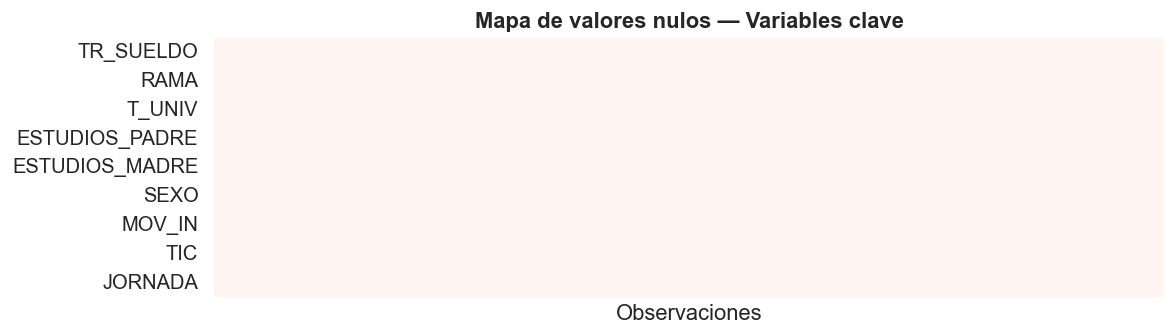

In [51]:
# ── 4.5 Heatmap de nulos (variables clave) ───────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 3))
sns.heatmap(
    df[vars_encontradas].isna().T,
    cbar=False, yticklabels=True, xticklabels=False,
    cmap='Reds', ax=ax
)
ax.set_title('Mapa de valores nulos — Variables clave', fontweight='bold')
ax.set_xlabel('Observaciones')
plt.tight_layout()
plt.savefig('../../outputs/figures/fig01_heatmap_nulos.png', bbox_inches='tight')
plt.show()

---
## 5. Tratamiento de la Variable Objetivo: `TR_SUELDO`

### 5.1 Codificación original (según diccionario INE)

| Valor | Significado |
|-------|-------------|
| 1     | < 700 €/mes |
| 2     | 700 – 999 €/mes |
| 3     | 1.000 – 1.499 €/mes |
| 4     | 1.500 – 1.999 €/mes *(moda esperada ~33%)* |
| 5     | 2.000 – 2.499 €/mes |
| 6     | 2.500 – 2.999 €/mes |
| 7     | ≥ 3.000 €/mes |
| NaN / vacío | Sin empleo (~12%) |
| 8 / 9 / otro | NS/NC (~3%) |

**Decisión:** Filtraremos el dataset de modelado para conservar **únicamente los 7 niveles ordinales válidos (1–7)**. Los registros sin empleo y NS/NC se excluyen del modelo principal (objetivo: predecir el tramo salarial de quien sí tiene empleo). Esta exclusión se documenta y justifica en el Executive Summary.

In [52]:
# ── 5.1 Distribución raw de TR_SUELDO antes de filtrar ──────────────────────
print('Distribución bruta de TR_SUELDO (incluyendo nulos y NS/NC):')
print(df['TR_SUELDO'].value_counts(dropna=False).sort_index())
print(f'\nTotal filas: {len(df):,}')
print(f'Nulos (sin empleo aprox.): {df["TR_SUELDO"].isna().sum():,} '
      f'({df["TR_SUELDO"].isna().mean()*100:.1f}%)')

Distribución bruta de TR_SUELDO (incluyendo nulos y NS/NC):
TR_SUELDO
     1399
1     475
2     743
3    2528
4    3354
5    1519
6     510
7     644
9     311
Name: count, dtype: int64

Total filas: 11,483
Nulos (sin empleo aprox.): 0 (0.0%)


In [53]:
# ── 5.2 Separar registros según situación ───────────────────────────────────
TRAMOS_VALIDOS = [1, 2, 3, 4, 5, 6, 7]

# Convertir a numérico (por si viene como string)
df['TR_SUELDO_NUM'] = pd.to_numeric(df['TR_SUELDO'], errors='coerce')

mask_sin_empleo = df['TR_SUELDO_NUM'].isna()
mask_nsnc       = df['TR_SUELDO_NUM'].notna() & ~df['TR_SUELDO_NUM'].isin(TRAMOS_VALIDOS)
mask_valido     = df['TR_SUELDO_NUM'].isin(TRAMOS_VALIDOS)

print('─'*45)
print(f'Sin empleo (NaN):  {mask_sin_empleo.sum():>6,} ({mask_sin_empleo.mean()*100:.1f}%)')
print(f'NS/NC / fuera rango: {mask_nsnc.sum():>4,} ({mask_nsnc.mean()*100:.1f}%)')
print(f'Tramos válidos (1–7):{mask_valido.sum():>4,} ({mask_valido.mean()*100:.1f}%)')
print('─'*45)

# Dataset de modelado
df_model = df[mask_valido].copy()
df_model['TR_SUELDO_NUM'] = df_model['TR_SUELDO_NUM'].astype(int)
print(f'\n✅ Dataset de modelado: {df_model.shape[0]:,} filas × {df_model.shape[1]:,} columnas')

─────────────────────────────────────────────
Sin empleo (NaN):   1,399 (12.2%)
NS/NC / fuera rango:  311 (2.7%)
Tramos válidos (1–7):9,773 (85.1%)
─────────────────────────────────────────────

✅ Dataset de modelado: 9,773 filas × 292 columnas


In [54]:
# ── 5.3 Etiquetas descriptivas para los tramos ───────────────────────────────
TRAMO_LABELS = {
    1: '< 700€',
    2: '700–999€',
    3: '1.000–1.499€',
    4: '1.500–1.999€',
    5: '2.000–2.499€',
    6: '2.500–2.999€',
    7: '≥ 3.000€'
}

df_model['TR_SUELDO_LABEL'] = df_model['TR_SUELDO_NUM'].map(TRAMO_LABELS)

# Crear también una versión binarizada para análisis complementarios
# Sueldo Alto: tramos 5-7 (≥2.000€); Sueldo Medio-Bajo: tramos 1-4 (<2.000€)
df_model['SUELDO_ALTO'] = (df_model['TR_SUELDO_NUM'] >= 5).astype(int)

print('Variable objetivo lista. Distribución final:')
dist = df_model['TR_SUELDO_NUM'].value_counts().sort_index()
dist_pct = (dist / dist.sum() * 100).round(1)
resumen = pd.DataFrame({'n': dist, '%': dist_pct, 'tramo': pd.Series(TRAMO_LABELS)})
print(resumen)

Variable objetivo lista. Distribución final:
      n     %         tramo
1   475  4.90        < 700€
2   743  7.60      700–999€
3  2528 25.90  1.000–1.499€
4  3354 34.30  1.500–1.999€
5  1519 15.50  2.000–2.499€
6   510  5.20  2.500–2.999€
7   644  6.60      ≥ 3.000€


---
## 6. Análisis Univariante

### 6.1 Variable objetivo: `TR_SUELDO`

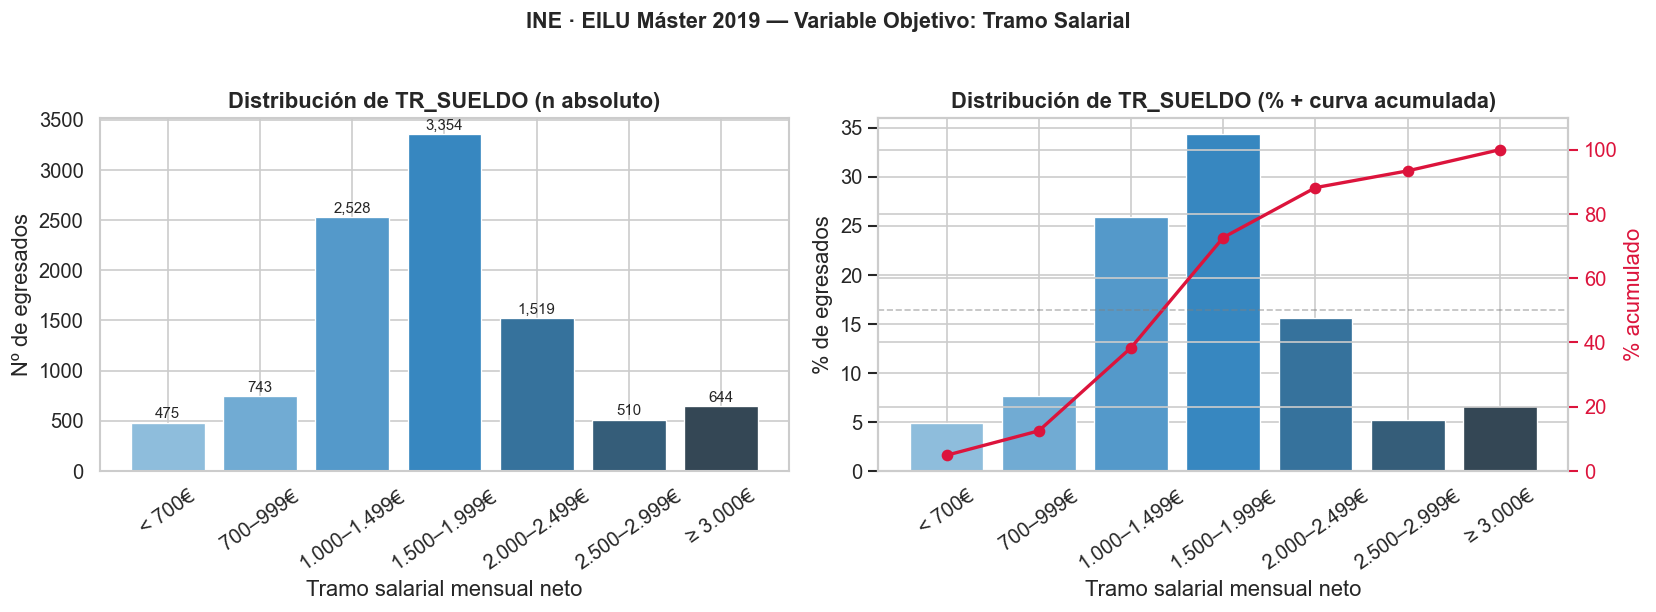


📌 Moda: Tramo 4 (1.500–1.999€) — 34.3% de los empleados


In [55]:
# ── 6.1 Distribución de TR_SUELDO ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Countplot
order = list(TRAMO_LABELS.keys())
labels_order = [TRAMO_LABELS[k] for k in order]

counts = df_model['TR_SUELDO_NUM'].value_counts().sort_index()
colors = sns.color_palette('Blues_d', len(order))

ax = axes[0]
bars = ax.bar(labels_order, counts.values, color=colors, edgecolor='white', linewidth=0.8)
ax.set_title('Distribución de TR_SUELDO (n absoluto)', fontweight='bold')
ax.set_xlabel('Tramo salarial mensual neto')
ax.set_ylabel('Nº de egresados')
ax.tick_params(axis='x', rotation=35)
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
            f'{bar.get_height():,.0f}', ha='center', va='bottom', fontsize=9)

# % acumulado
ax2 = axes[1]
pcts = (counts / counts.sum() * 100)
cum_pcts = pcts.cumsum()
ax2.bar(labels_order, pcts.values, color=colors, edgecolor='white', linewidth=0.8)
ax2_twin = ax2.twinx()
ax2_twin.plot(labels_order, cum_pcts.values, color='crimson', marker='o',
              linewidth=2, label='% acumulado')
ax2_twin.set_ylabel('% acumulado', color='crimson')
ax2_twin.tick_params(axis='y', colors='crimson')
ax2_twin.set_ylim(0, 110)
ax2.set_title('Distribución de TR_SUELDO (% + curva acumulada)', fontweight='bold')
ax2.set_xlabel('Tramo salarial mensual neto')
ax2.set_ylabel('% de egresados')
ax2.tick_params(axis='x', rotation=35)
ax2_twin.axhline(50, linestyle='--', color='gray', alpha=0.5, linewidth=1)

fig.suptitle('INE · EILU Máster 2019 — Variable Objetivo: Tramo Salarial',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../../outputs/figures/fig02_dist_tr_sueldo.png', bbox_inches='tight')
plt.show()

moda = counts.idxmax()
print(f'\n📌 Moda: Tramo {moda} ({TRAMO_LABELS[moda]}) — {pcts[moda]:.1f}% de los empleados')

### 6.2 Variables predictoras categóricas

In [56]:
# ── Diccionarios de decodificación según diccionario INE ─────────────────────
DECODE = {
    'SEXO': {1: 'Hombre', 2: 'Mujer'},
    'RAMA': {1: 'Artes y Hum.', 2: 'Ciencias', 3: 'C. Sociales',
             4: 'Ingeniería', 5: 'Salud'},
    'T_UNIV': {1: 'Pública presencial', 2: 'Pública distancia',
               3: 'Privada presencial', 4: 'Privada distancia'},
    'MOV_IN': {1: 'Sí (se movió)', 2: 'No (se quedó)'},
    'TIC': {1: 'Básico', 2: 'Intermedio', 3: 'Avanzado'},
    'JORNADA': {1: 'Parcial', 2: 'Completa'},
    'ESTUDIOS_PADRE': {
        1: 'Sin alfabetizar', 2: 'Primaria incompleta', 3: 'Primaria',
        4: 'ESO/EGB', 5: 'Bachillerato/FP medio', 6: 'FP superior',
        7: 'Universitarios medios', 8: 'Universitarios superiores', 9: 'NS/NC'
    },
    'ESTUDIOS_MADRE': {
        1: 'Sin alfabetizar', 2: 'Primaria incompleta', 3: 'Primaria',
        4: 'ESO/EGB', 5: 'Bachillerato/FP medio', 6: 'FP superior',
        7: 'Universitarios medios', 8: 'Universitarios superiores', 9: 'NS/NC'
    },
}

# Crear columnas decodificadas
for var, mapping in DECODE.items():
    if var in df_model.columns:
        df_model[var + '_DEC'] = pd.to_numeric(df_model[var], errors='coerce').map(mapping)

print('✅ Columnas decodificadas creadas.')

✅ Columnas decodificadas creadas.


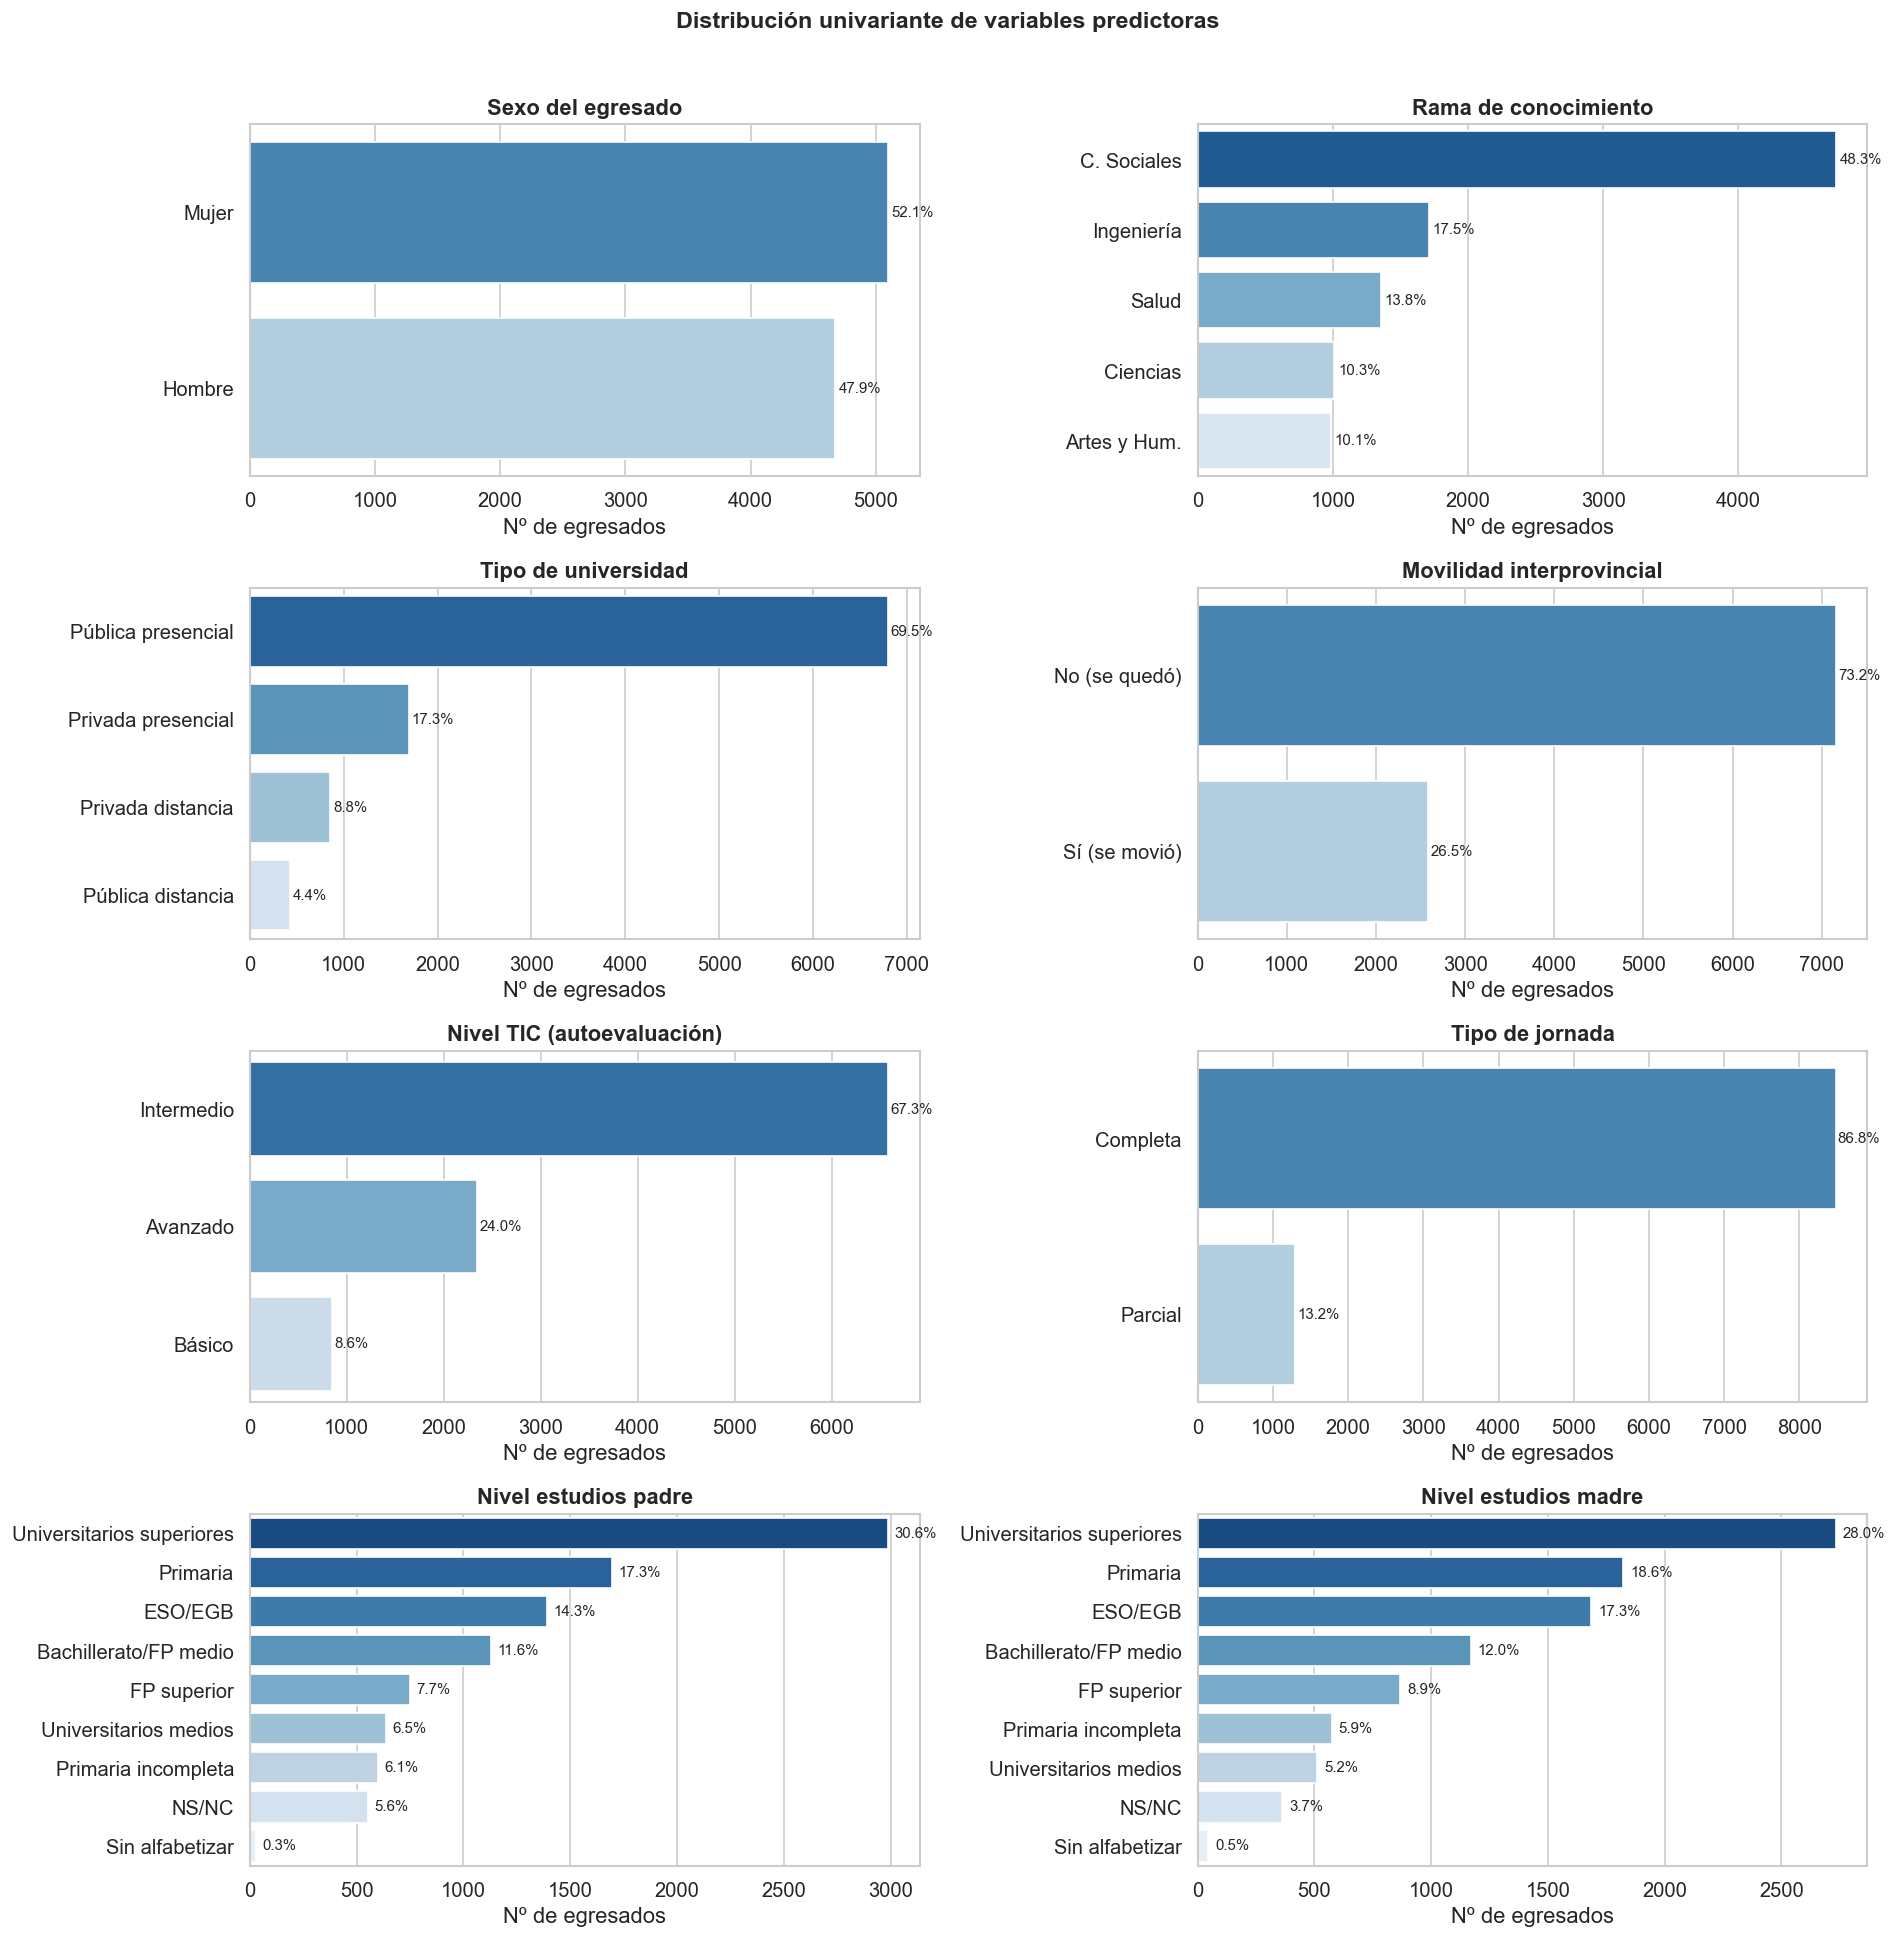

In [57]:
# ── 6.2 Countplots de todas las variables predictoras ───────────────────────
VARS_PLOT = [
    ('SEXO_DEC',           'Sexo del egresado'),
    ('RAMA_DEC',           'Rama de conocimiento'),
    ('T_UNIV_DEC',         'Tipo de universidad'),
    ('MOV_IN_DEC',         'Movilidad interprovincial'),
    ('TIC_DEC',            'Nivel TIC (autoevaluación)'),
    ('JORNADA_DEC',        'Tipo de jornada'),
    ('ESTUDIOS_PADRE_DEC', 'Nivel estudios padre'),
    ('ESTUDIOS_MADRE_DEC', 'Nivel estudios madre'),
]

# Filtramos sólo las que existen
VARS_PLOT = [(v, t) for v, t in VARS_PLOT if v in df_model.columns]

n_vars = len(VARS_PLOT)
ncols = 2
nrows = (n_vars + 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 4))
axes = axes.flatten()

for idx, (var, title) in enumerate(VARS_PLOT):
    ax = axes[idx]
    order_v = df_model[var].value_counts().index.tolist()
    sns.countplot(data=df_model, y=var, order=order_v, ax=ax,
                  palette='Blues_r', edgecolor='white')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Nº de egresados')
    ax.set_ylabel('')
    # Añadir porcentajes
    total = len(df_model)
    for patch in ax.patches:
        width = patch.get_width()
        ax.text(width + total * 0.003, patch.get_y() + patch.get_height() / 2,
                f'{width/total*100:.1f}%', va='center', fontsize=9)

# Ocultar ejes sobrantes
for idx in range(len(VARS_PLOT), len(axes)):
    axes[idx].set_visible(False)

fig.suptitle('Distribución univariante de variables predictoras',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../../outputs/figures/fig03_univariante_predictoras.png', bbox_inches='tight')
plt.show()

> **📝 Comentario — Análisis Univariante:**
> 
> *[Espacio para añadir vuestros comentarios sobre los patrones observados en cada variable. Por ejemplo: distribución de sexo, predominio de la pública presencial, nivel TIC mayoritariamente intermedio, etc.]*

---
## 7. Análisis Bivariante y Multivariante

### 7.1 Barras apiladas al 100%: Predictor vs. TR_SUELDO

Este tipo de gráfico permite ver cómo varía la **distribución del tramo salarial** dentro de cada categoría del predictor.

In [58]:
# ── Función auxiliar: Barras apiladas al 100% ────────────────────────────────
def plot_stacked_100(df, var, title, ax, palette='Blues'):
    """Gráfico de barras apiladas normalizadas al 100%."""
    ct = pd.crosstab(df[var], df['TR_SUELDO_NUM'])
    ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100
    ct_pct.columns = [TRAMO_LABELS.get(c, str(c)) for c in ct_pct.columns]
    colors = sns.color_palette(palette, ct_pct.shape[1])
    ct_pct.plot(kind='barh', stacked=True, ax=ax, color=colors,
                edgecolor='white', linewidth=0.5, width=0.7)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('% de egresados')
    ax.set_ylabel('')
    ax.xaxis.set_major_formatter(mtick.PercentFormatter())
    ax.legend(loc='lower right', fontsize=7, title='Tramo', title_fontsize=8)
    ax.set_xlim(0, 100)
    return ct

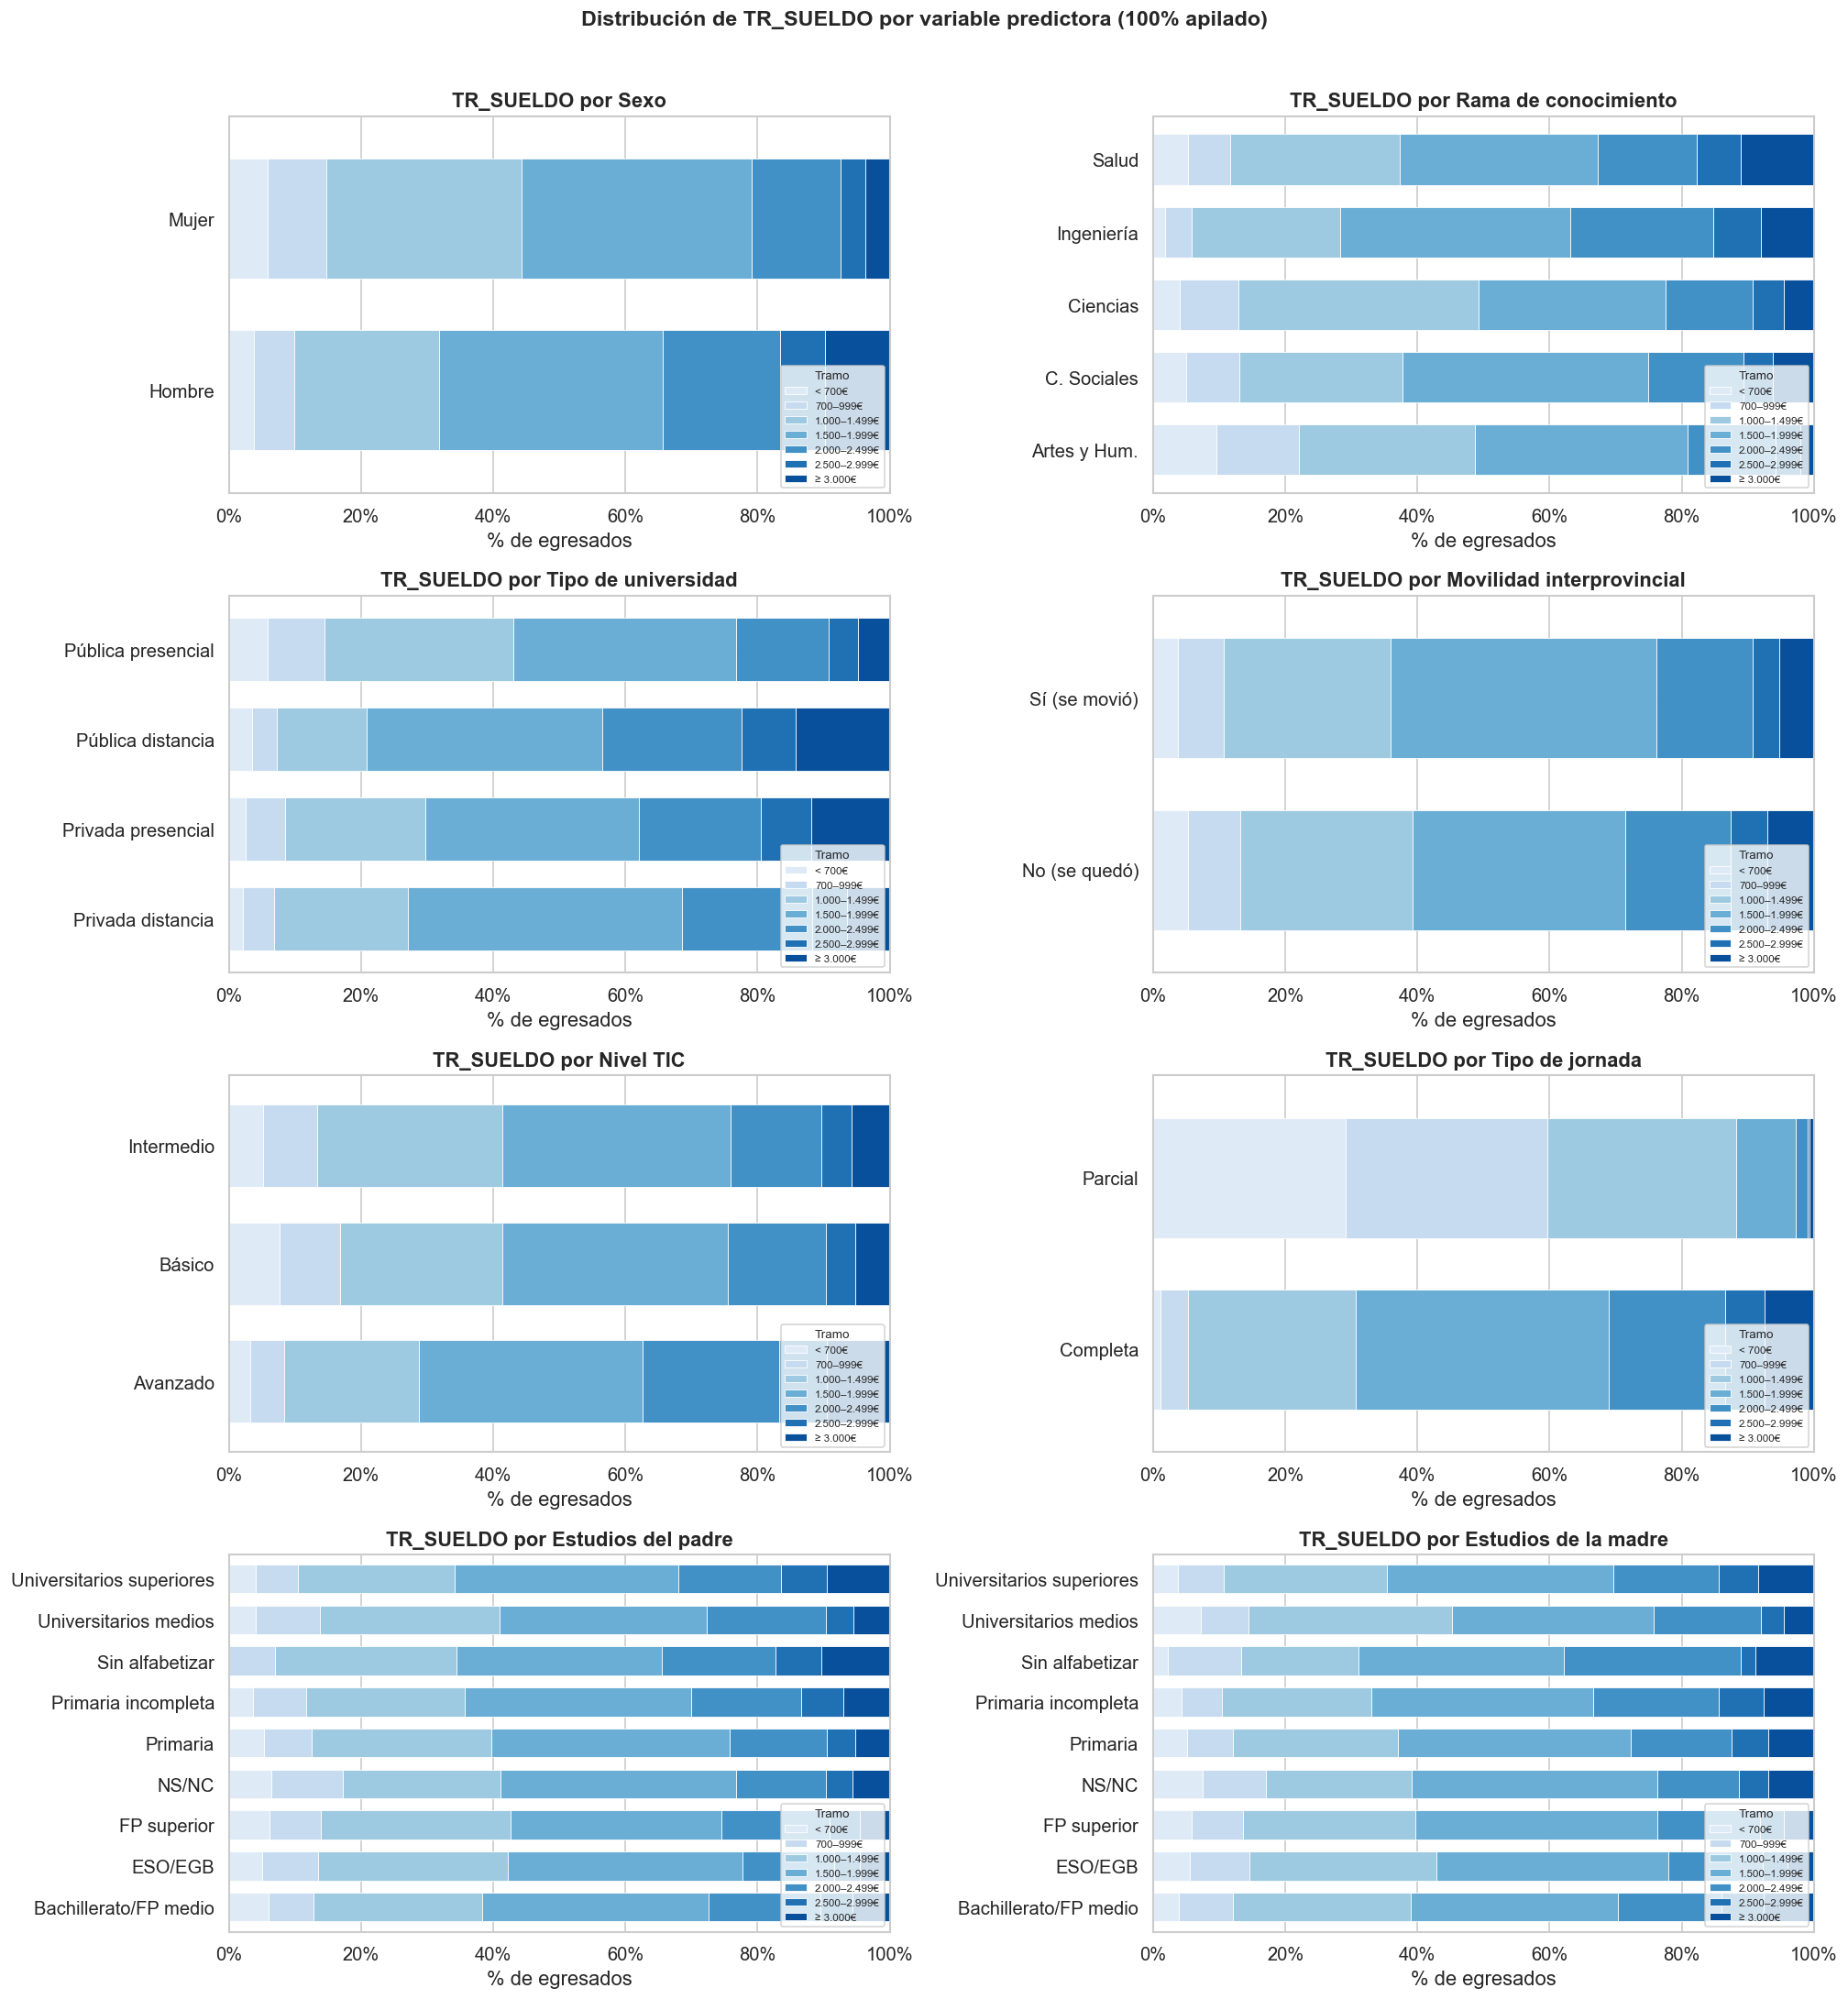

In [59]:
# ── 7.1 Barras apiladas para cada predictor ──────────────────────────────────
BIVARIANTE_VARS = [
    ('SEXO_DEC',           'TR_SUELDO por Sexo'),
    ('RAMA_DEC',           'TR_SUELDO por Rama de conocimiento'),
    ('T_UNIV_DEC',         'TR_SUELDO por Tipo de universidad'),
    ('MOV_IN_DEC',         'TR_SUELDO por Movilidad interprovincial'),
    ('TIC_DEC',            'TR_SUELDO por Nivel TIC'),
    ('JORNADA_DEC',        'TR_SUELDO por Tipo de jornada'),
    ('ESTUDIOS_PADRE_DEC', 'TR_SUELDO por Estudios del padre'),
    ('ESTUDIOS_MADRE_DEC', 'TR_SUELDO por Estudios de la madre'),
]
BIVARIANTE_VARS = [(v, t) for v, t in BIVARIANTE_VARS if v in df_model.columns]

ncols = 2
nrows = (len(BIVARIANTE_VARS) + 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(17, nrows * 4.5))
axes = axes.flatten()

for idx, (var, title) in enumerate(BIVARIANTE_VARS):
    plot_stacked_100(df_model, var, title, axes[idx])

for idx in range(len(BIVARIANTE_VARS), len(axes)):
    axes[idx].set_visible(False)

fig.suptitle('Distribución de TR_SUELDO por variable predictora (100% apilado)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../../outputs/figures/fig04_bivariante_stacked.png', bbox_inches='tight')
plt.show()

> **📝 Comentario — Análisis Bivariante (barras apiladas):**
>
> *[Describir los patrones más llamativos. Por ejemplo: ¿Los egresados de Ingeniería y Salud tienen mayor concentración en tramos altos? ¿La movilidad interprovincial se asocia con tramos superiores? ¿El nivel TIC Avanzado desplaza la distribución hacia la derecha?]*

In [60]:
# ── 7.2 Tablas de contingencia detalladas ───────────────────────────────────
for var, title in BIVARIANTE_VARS:
    print(f'\n{'='*60}')
    print(f'  {title}')
    print('='*60)
    ct = pd.crosstab(
        df_model[var],
        df_model['TR_SUELDO_NUM'],
        margins=True, margins_name='Total'
    )
    ct.columns = [TRAMO_LABELS.get(c, str(c)) for c in ct.columns[:-1]] + ['Total']
    display(ct)


  TR_SUELDO por Sexo


,< 700€,700–999€,1.000–1.499€,1.500–1.999€,2.000–2.499€,2.500–2.999€,≥ 3.000€,Total
SEXO_DEC,,,,,,,,
Hombre,175,289,1023,1582,834,320,455,4678
Mujer,300,454,1505,1772,685,190,189,5095
Total,475,743,2528,3354,1519,510,644,9773



  TR_SUELDO por Rama de conocimiento


,< 700€,700–999€,1.000–1.499€,1.500–1.999€,2.000–2.499€,2.500–2.999€,≥ 3.000€,Total
RAMA_DEC,,,,,,,,
Artes y Hum.,94,123,262,316,131,37,20,983
C. Sociales,239,375,1166,1753,681,213,292,4719
Ciencias,41,89,367,285,133,48,46,1009
Ingeniería,30,70,384,596,370,122,137,1709
Salud,71,86,349,404,204,90,149,1353
Total,475,743,2528,3354,1519,510,644,9773



  TR_SUELDO por Tipo de universidad


...

,< 700€,700–999€,1.000–1.499€,1.500–1.999€,2.000–2.499€,2.500–2.999€,≥ 3.000€,Total
JORNADA_DEC,,,,,,,,
Completa,99,347,2159,3238,1495,506,636,8480
Parcial,376,396,369,116,24,4,8,1293
Total,475,743,2528,3354,1519,510,644,9773



  TR_SUELDO por Estudios del padre


,< 700€,700–999€,1.000–1.499€,1.500–1.999€,2.000–2.499€,2.500–2.999€,≥ 3.000€,Total
ESTUDIOS_PADRE_DEC,,,,,,,,
Bachillerato/FP medio,68,77,287,387,192,54,64,1129
ESO/EGB,69,119,399,495,194,54,63,1393
FP superior,46,58,217,240,123,34,34,752
NS/NC,35,60,132,197,75,22,31,552
Primaria,89,124,460,610,251,71,89,1694
Primaria incompleta,22,48,144,206,100,38,42,600
Sin alfabetizar,0,2,8,9,5,2,3,29
Universitarios medios,26,62,173,200,115,27,35,638
Universitarios superiores,120,193,708,1010,464,208,283,2986



  TR_SUELDO por Estudios de la madre


,< 700€,700–999€,1.000–1.499€,1.500–1.999€,2.000–2.499€,2.500–2.999€,≥ 3.000€,Total
ESTUDIOS_MADRE_DEC,,,,,,,,
Bachillerato/FP medio,45,97,314,367,183,74,89,1169
ESO/EGB,94,151,479,591,240,65,66,1686
FP superior,51,67,227,318,134,32,39,868
NS/NC,27,35,80,135,45,16,25,363
Primaria,93,126,457,642,278,101,125,1822
Primaria incompleta,25,35,130,193,109,39,44,575
Sin alfabetizar,1,5,8,14,12,1,4,45
Universitarios medios,37,37,158,157,83,18,23,513
Universitarios superiores,102,190,675,937,435,164,229,2732


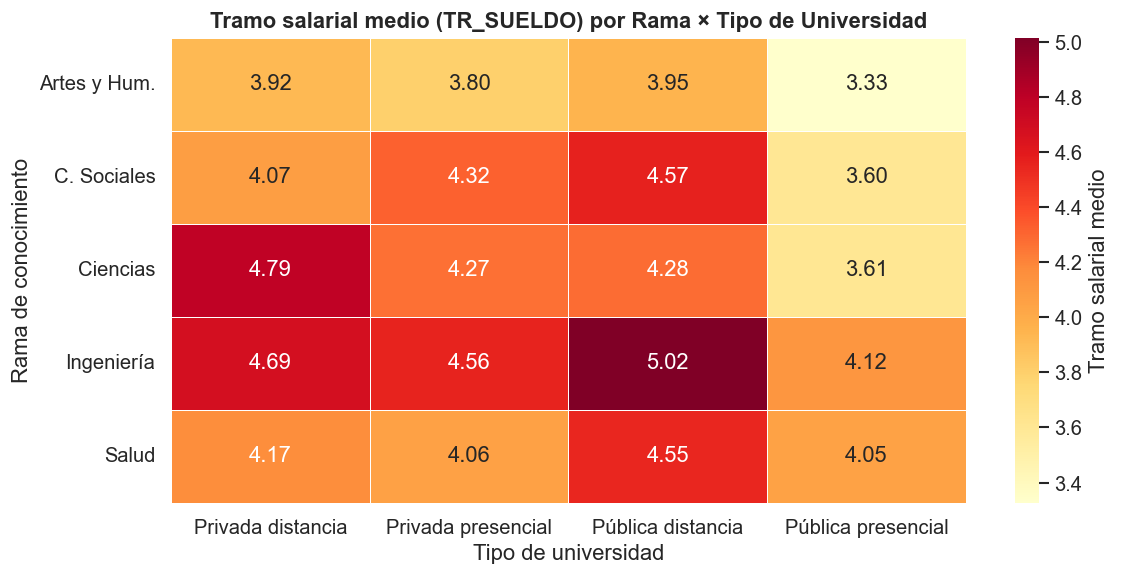

In [61]:
# ── 7.3 Heatmap de sueldo medio por RAMA x T_UNIV (multivariante) ───────────
if 'RAMA_DEC' in df_model.columns and 'T_UNIV_DEC' in df_model.columns:
    pivot = df_model.pivot_table(
        values='TR_SUELDO_NUM', index='RAMA_DEC', columns='T_UNIV_DEC', aggfunc='mean'
    )
    fig, ax = plt.subplots(figsize=(10, 5))
    sns.heatmap(
        pivot, annot=True, fmt='.2f', cmap='YlOrRd',
        linewidths=0.5, ax=ax, cbar_kws={'label': 'Tramo salarial medio'}
    )
    ax.set_title('Tramo salarial medio (TR_SUELDO) por Rama × Tipo de Universidad',
                 fontweight='bold')
    ax.set_xlabel('Tipo de universidad')
    ax.set_ylabel('Rama de conocimiento')
    plt.tight_layout()
    plt.savefig('../../outputs/figures/fig05_heatmap_rama_tuniv.png', bbox_inches='tight')
    plt.show()

> **📝 Comentario — Heatmap multivariante (RAMA × T_UNIV):**
>
> *[¿Hay interacciones entre el tipo de universidad y la rama que afecten al sueldo esperado? ¿Destaca alguna combinación Rama-Universidad como especialmente favorable?]*

---
## 8. Pruebas Estadísticas: Chi-cuadrado y V de Cramér

La **V de Cramér** mide la fuerza de asociación entre dos variables categóricas (0 = sin asociación, 1 = asociación perfecta). Es independiente del tamaño muestral, a diferencia del p-valor del Chi-cuadrado.

| V de Cramér | Interpretación |
|------------|----------------|
| < 0.10     | Asociación débil |
| 0.10–0.20  | Asociación moderada |
| > 0.20     | Asociación fuerte |

In [62]:
# ── Función: Chi-cuadrado + V de Cramér ─────────────────────────────────────
def cramers_v(var1_series, var2_series):
    """Calcula Chi2, p-valor y V de Cramér entre dos variables categóricas."""
    ct = pd.crosstab(var1_series.dropna(), var2_series.dropna())
    chi2, p, dof, expected = chi2_contingency(ct)
    n = ct.sum().sum()
    k = min(ct.shape) - 1
    v = np.sqrt(chi2 / (n * k)) if (n * k) > 0 else 0
    return chi2, p, dof, v, n

# ── 8.1 Tabla de resultados ───────────────────────────────────────────────────
resultados = []
VARS_ORIGINALES = ['SEXO', 'RAMA', 'T_UNIV', 'ESTUDIOS_PADRE', 'ESTUDIOS_MADRE',
                   'MOV_IN', 'TIC', 'JORNADA']
VARS_ORIGINALES = [v for v in VARS_ORIGINALES if v in df_model.columns]

for var in VARS_ORIGINALES:
    serie = pd.to_numeric(df_model[var], errors='coerce')
    try:
        chi2, p, dof, v, n = cramers_v(serie, df_model['TR_SUELDO_NUM'])
        resultados.append({
            'Variable': var,
            'Chi²': round(chi2, 2),
            'p-valor': p,
            'GL (dof)': dof,
            'V Cramér': round(v, 4),
            'n válido': n,
            'Sig. (α=0.05)': '✅ Sí' if p < 0.05 else '❌ No'
        })
    except Exception as e:
        resultados.append({'Variable': var, 'Chi²': None, 'p-valor': None,
                           'GL (dof)': None, 'V Cramér': None,
                           'n válido': None, 'Sig. (α=0.05)': f'Error: {e}'})

df_stats = pd.DataFrame(resultados).sort_values('V Cramér', ascending=False)
df_stats['p-valor'] = df_stats['p-valor'].apply(
    lambda p: f'{p:.2e}' if pd.notna(p) else 'N/A')
df_stats

,Variable,Chi²,p-valor,GL (dof),V Cramér,n válido,Sig. (α=0.05)
7,JORNADA,3449.56,0.00e+00,6,0.59,9773,✅ Sí
0,SEXO,312.60,1.63e-64,6,0.18,9773,✅ Sí
2,T_UNIV,382.07,4.97e-70,18,0.11,9773,✅ Sí
1,RAMA,391.44,4.29e-68,24,0.10,9773,✅ Sí
6,TIC,213.64,1.85e-35,18,0.09,9773,✅ Sí
5,MOV_IN,77.11,1.46e-11,12,0.06,9749,✅ Sí
3,ESTUDIOS_PADRE,158.19,1.10e-13,48,0.05,9773,✅ Sí
4,ESTUDIOS_MADRE,142.23,2.90e-11,48,0.05,9773,✅ Sí


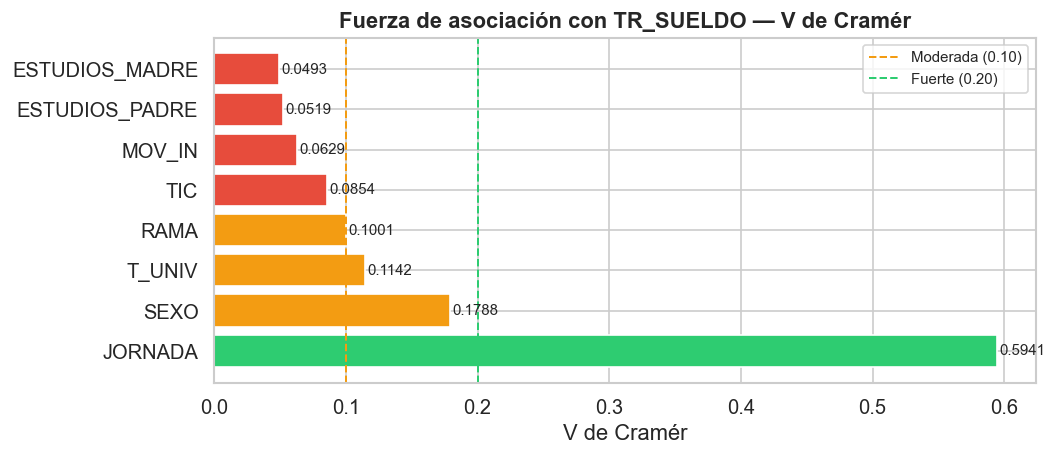

In [63]:
# ── 8.2 Visualización ranking de V de Cramér ─────────────────────────────────
df_stats_plot = df_stats[df_stats['V Cramér'].notna()].copy()

fig, ax = plt.subplots(figsize=(9, 4))
colors_v = ['#2ecc71' if v > 0.20 else '#f39c12' if v > 0.10 else '#e74c3c'
            for v in df_stats_plot['V Cramér']]
bars = ax.barh(df_stats_plot['Variable'], df_stats_plot['V Cramér'],
               color=colors_v, edgecolor='white')
ax.axvline(0.10, linestyle='--', color='#f39c12', linewidth=1.2, label='Moderada (0.10)')
ax.axvline(0.20, linestyle='--', color='#2ecc71', linewidth=1.2, label='Fuerte (0.20)')
ax.set_xlabel('V de Cramér')
ax.set_title('Fuerza de asociación con TR_SUELDO — V de Cramér', fontweight='bold')
ax.legend(fontsize=9)
for bar, val in zip(bars, df_stats_plot['V Cramér']):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('../../outputs/figures/fig06_cramer_v.png', bbox_inches='tight')
plt.show()

> **📝 Comentario — Chi-cuadrado y V de Cramér:**
>
> *[Interpretar los resultados estadísticos. ¿Qué variables muestran asociación más fuerte con TR_SUELDO? ¿Alguna resulta sorprendentemente débil? ¿Coincide con la intuición de negocio?]*
>
> *Ejemplo: «La variable JORNADA presenta la V de Cramér más alta (X.XX), lo que es esperable dado que la jornada completa está correlacionada con mejores salarios. Por el contrario, SEXO muestra una asociación moderada (X.XX), lo que merece un análisis de fairness en fases posteriores.»*

---
## 10. Conclusiones del EDA

> **📝 Párrafo de conclusiones — [A completar por el grupo]:**
>
> *El análisis exploratorio del dataset EILU_MAST_2019 (INE) sobre [N] egresados de máster del curso 2013/14 nos ha permitido extraer las siguientes conclusiones relevantes para nuestro objetivo predictivo:*
>
> *1. **Variable objetivo:** `TR_SUELDO` presenta una distribución claramente unimodal con moda en el tramo 4 (1.500–1.999€), que concentra aproximadamente el 33% de los empleados. Los extremos (tramos 1 y 7) son poco frecuentes, lo que puede dificultar la predicción de los tramos más bajos y más altos. Hemos excluido el ~12% de registros sin empleo y el ~3% de NS/NC, quedando [N] observaciones válidas.*
>
> *2. **Variables con mayor asociación estadística (V de Cramér):** [COMPLETAR con los resultados reales]. Esto sugiere que [interpretación de negocio].*
>
> *3. **Patrones bivariantes destacados:** [COMPLETAR. Por ejemplo: los egresados de Ingeniería y Ciencias de la Salud muestran distribuciones desplazadas hacia tramos altos; la movilidad interprovincial se asocia con tramos salariales superiores; el nivel TIC avanzado duplica la presencia en tramos 5–7.]*
>
> *4. **Decisiones de preprocesado:** Hemos optado por imputar los valores NS/NC en las variables de capital educativo familiar con la moda, preservando la máxima cantidad de información. El encoding respeta la naturaleza ordinal de `TIC` y `ESTUDIOS_PADRE/MADRE`, mientras que `RAMA` y `T_UNIV` se codifican mediante One-Hot dada su naturaleza nominal.*
>
> *5. **Implicación para el modelado:** Las variables de mayor poder predictivo anticipado son [COMPLETAR]. La naturaleza ordinal de la variable objetivo hace recomendable comparar modelos de regresión ordinal con modelos basados en árboles que no asumen proporcionalidad de odds.*

In [64]:
# ── Resumen ejecutivo del EDA (tabla resumen) ─────────────────────────────────
print('='*60)
print('  RESUMEN EJECUTIVO — EDA FASE 1')
print('='*60)
print(f'  Dataset          : EILU_MAST_2019 (Máster)')
print(f'  Filas originales : {df_raw.shape[0]:>10,}')
print(f'  Sin empleo excl. : {mask_sin_empleo.sum():>10,} ({mask_sin_empleo.mean()*100:.1f}%)')
print(f'  NS/NC excluidos  : {mask_nsnc.sum():>10,} ({mask_nsnc.mean()*100:.1f}%)')
print(f'  Filas modelado   : {df_model.shape[0]:>10,}')
print(f'  Variables totales: {df_raw.shape[1]:>10,}')
print(f'  Features modelo  : {df_encoded.shape[1]-1:>10,}')
print(f'  Target           : TR_SUELDO_NUM (ordinal 1–7)')
print(f'  Moda target      : Tramo 4 (1.500–1.999€)')
print('='*60)
print('\nTop variables por V de Cramér:')
print(df_stats[['Variable', 'V Cramér', 'Sig. (α=0.05)']].head(5).to_string(index=False))

  RESUMEN EJECUTIVO — EDA FASE 1
  Dataset          : EILU_MAST_2019 (Máster)
  Filas originales :     11,483
  Sin empleo excl. :      1,399 (12.2%)
  NS/NC excluidos  :        311 (2.7%)
  Filas modelado   :      9,773
  Variables totales:        291
  Features modelo  :         16
  Target           : TR_SUELDO_NUM (ordinal 1–7)
  Moda target      : Tramo 4 (1.500–1.999€)

Top variables por V de Cramér:
Variable  V Cramér Sig. (α=0.05)
 JORNADA      0.59          ✅ Sí
    SEXO      0.18          ✅ Sí
  T_UNIV      0.11          ✅ Sí
    RAMA      0.10          ✅ Sí
     TIC      0.09          ✅ Sí


---
### 📌 Propuesta de variable objetivo — Justificación

**Variable objetivo elegida:** `TR_SUELDO` (tramo salarial mensual neto)

**Tipo:** Multiclase **ordinal** — 7 categorías ordenadas desde `1` (<700€) hasta `7` (≥3.000€)

**Transformación aplicada:**
- Se han excluido los registros sin empleo (~12%) y NS/NC (~3%), dado que el objetivo del modelo es **predecir el tramo salarial de egresados que acceden al mercado laboral**, no modelar la probabilidad de empleo (esa sería una pregunta de investigación diferente, cubierta en la Pregunta A del dataset de Grado).
- La variable se mantiene como numérica ordinal [1–7], respetando el orden natural de los tramos salariales.
- Como variable derivada auxiliar, se ha construido `SUELDO_ALTO` (binaria: tramos 5–7 vs. 1–4) para análisis complementarios.

**Justificación de negocio:**
La variable `TR_SUELDO` es el indicador más directo del **ROI de la inversión en un máster** para el alumno. Una herramienta de admisiones que prediga el tramo salarial esperado permite al equipo de ventas argumentar de forma cuantitativa la rentabilidad del programa ante cada perfil de candidato.

**Dataset elegido:** EILU_MAST_2019 (Máster)

**Justificación de la elección del dataset:** El dataset de Máster es el más adecuado porque (1) el modelo de negocio propuesto es específico de escuelas de posgrado, (2) los titulados de máster tienen una distribución salarial con mayor varianza y más representación en tramos medios-altos, y (3) las variables de idiomas (`IDIOMAS`, `NIV_ID1`, `NIV_ID2`) disponibles en el dataset de Máster enriquecen el análisis de competencias.

---
*Fin de la Fase 1 — EDA y Preprocesado*  
*Siguiente fase: `02_modelo_base.ipynb` — Regresión Logística Ordinal como modelo base*